# Tarea 2 — Busqueda informada A* en una cuadricula 10x10

**Asignatura:** Inteligencia Artificial — Unidad II: Resolucion de problemas mediante busqueda
**Actividad:** Guia A3 — Implementacion del algoritmo A* para busqueda del camino de menor costo

Este notebook implementa el algoritmo **A\*** para encontrar el camino de menor costo entre dos posiciones de una cuadricula 10x10 evitando obstaculos, con movimientos horizontales, verticales y diagonales. Ademas compara A* con **Dijkstra** (A* con `h(n)=0`).

Las clases `Espacio` (representa la cuadricula, obstaculos, inicio y meta) y `Explorador` (agente de busqueda A*/Dijkstra) estan definidas en `Espacio.py` y `Explorador.py`, en esta misma carpeta.

## Parte 1 — Definicion del problema

Importamos las clases del proyecto y definimos:
- las dimensiones de la cuadricula (10x10);
- las coordenadas de inicio y meta;
- el conjunto de obstaculos (suficientes para obligar a un desvio respecto de la linea recta hacia la meta).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from Espacio import Espacio
from Explorador import Explorador, MOVIMIENTOS

In [2]:
FILAS, COLUMNAS = 10, 10
INICIO = (1, 1)
META = (9, 9)

OBSTACULOS = {
    (1, 2), (2, 2), (3, 2), (4, 2),
    (5, 2), (5, 3), (5, 4), (5, 5),
}

espacio = Espacio(FILAS, COLUMNAS, OBSTACULOS, INICIO, META)
print(f"Cuadricula {espacio.filas}x{espacio.columnas} | inicio={espacio.inicio} | meta={espacio.meta}")
print(f"Obstaculos ({len(espacio.obstaculos)}):", sorted(espacio.obstaculos))

Cuadricula 10x10 | inicio=(1, 1) | meta=(9, 9)
Obstaculos (8): [(1, 2), (2, 2), (3, 2), (4, 2), (5, 2), (5, 3), (5, 4), (5, 5)]


## Parte 2 — Representacion

Funcion auxiliar para dibujar la cuadricula: celdas libres en blanco, obstaculos en negro, inicio en verde y meta en rojo. Opcionalmente resalta los nodos explorados (celeste) y el camino final (linea naranja). Los ejes muestran fila y columna para ubicar cualquier celda.

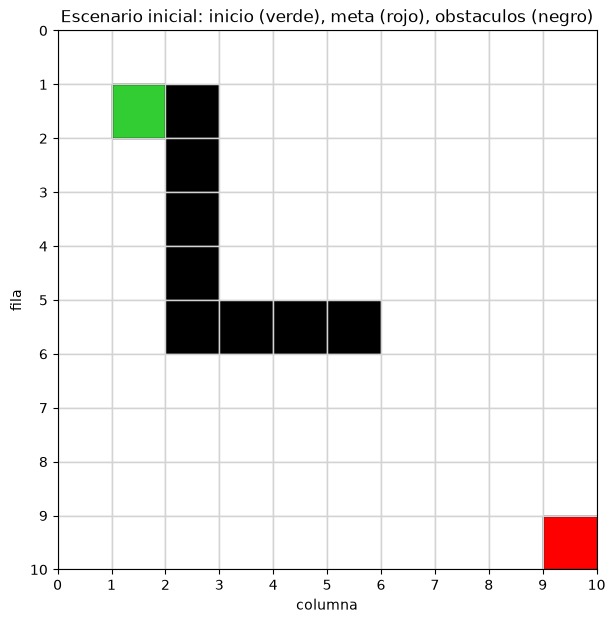

In [3]:
def graficar_espacio(espacio, camino=None, explorados=None, titulo="Espacio de busqueda"):
    fig, ax = plt.subplots(figsize=(7, 7))

    for fila in range(espacio.filas):
        for columna in range(espacio.columnas):
            color = "black" if (fila, columna) in espacio.obstaculos else "white"
            ax.add_patch(patches.Rectangle((columna, fila), 1, 1, facecolor=color, edgecolor="lightgray"))

    if explorados:
        for celda in explorados:
            if celda not in (espacio.inicio, espacio.meta):
                ax.add_patch(patches.Rectangle((celda[1], celda[0]), 1, 1, facecolor="#bcdffb", edgecolor="lightgray"))

    if camino:
        xs = [c[1] + 0.5 for c in camino]
        ys = [c[0] + 0.5 for c in camino]
        ax.plot(xs, ys, color="orange", linewidth=2, marker="o", markersize=4, zorder=3)

    fila_i, col_i = espacio.inicio
    fila_m, col_m = espacio.meta
    ax.add_patch(patches.Rectangle((col_i, fila_i), 1, 1, facecolor="limegreen", edgecolor="black"))
    ax.add_patch(patches.Rectangle((col_m, fila_m), 1, 1, facecolor="red", edgecolor="black"))

    ax.set_xlim(0, espacio.columnas)
    ax.set_ylim(0, espacio.filas)
    ax.set_xticks(range(espacio.columnas + 1))
    ax.set_yticks(range(espacio.filas + 1))
    ax.invert_yaxis()
    ax.set_xlabel("columna")
    ax.set_ylabel("fila")
    ax.set_title(titulo)
    ax.set_aspect("equal")
    ax.grid(True, color="lightgray")
    plt.show()


graficar_espacio(espacio, titulo="Escenario inicial: inicio (verde), meta (rojo), obstaculos (negro)")

## Parte 3 — Modelo de movimiento

Implementado en `Explorador.py`:

- **`MOVIMIENTOS`**: las 8 direcciones posibles (4 rectas + 4 diagonales) con su costo: 10 para movimientos horizontales/verticales, 14 para diagonales.
- **`Espacio.es_transitable(celda)`**: valida limites de la cuadricula y que la celda no sea un obstaculo.
- **`Explorador._movimiento_valido(...)`**: ademas de lo anterior, en un movimiento diagonal exige que las **dos celdas ortogonales laterales** tambien sean transitables, para no atravesar una esquina bloqueada por dos obstaculos (regla 7 de la guia).

In [4]:
for dfila, dcolumna, costo in MOVIMIENTOS:
    print(f"({dfila:+d}, {dcolumna:+d}) -> costo {costo}")

(-1, +0) -> costo 10
(+1, +0) -> costo 10
(+0, -1) -> costo 10
(+0, +1) -> costo 10
(-1, -1) -> costo 14
(-1, +1) -> costo 14
(+1, -1) -> costo 14
(+1, +1) -> costo 14


## Parte 4 — Heuristica

Como los movimientos incluyen diagonales, la distancia Manhattan (usada en el ejemplo 5x5 de clase) deja de ser admisible: sobreestima el costo real de un paso diagonal. En su lugar se usa la **distancia octil**:

`dx = |fila - fila_meta|`, `dy = |columna - columna_meta|`

`h(n) = 10 * max(dx, dy) + 4 * min(dx, dy)`

Esto modela recorrer primero tantas diagonales como sea posible (costo 14 cada una) y completar el resto en linea recta (costo 10 cada una), que es la forma mas barata de moverse en esta grilla.

In [5]:
explorador_demo = Explorador(espacio)
for celda in [espacio.inicio, (5, 5), espacio.meta]:
    print(f"h{celda} = {explorador_demo.heuristica(celda)}")

h(1, 1) = 112
h(5, 5) = 56
h(9, 9) = 0


## Parte 5 — Algoritmo A*

`Explorador.buscar()` implementa A* con:

- **OPEN**: cola de prioridad (`heapq`) de tuplas `(f, orden, nodo)`.
- **CLOSED** (`cerrados`): set de celdas ya expandidas.
- **`mejor_g`**: mejor `g(n)` conocido por celda; si se descubre un camino mas barato a una celda ya vista, se actualiza `g`, `f` y el padre (seccion 11 de la guia).
- La busqueda se detiene cuando la meta se **extrae** de OPEN, no cuando se genera por primera vez, lo que garantiza el camino optimo.

Ejecutamos A* sobre el escenario definido y mostramos la traza de los nodos expandidos (paso, celda, g, h, f).

In [6]:
explorador_astar = Explorador(espacio, usar_heuristica=True)
resultado_astar = explorador_astar.buscar()

pd.DataFrame(explorador_astar.pasos)

,paso,celda,g,h,f
0,1,"(1, 1)",0,112,112
1,2,"(2, 1)",10,108,118
2,3,"(3, 1)",20,104,124
3,4,"(4, 1)",30,100,130
4,5,"(0, 1)",10,122,132
5,6,"(1, 0)",10,122,132
6,7,"(2, 0)",14,118,132
7,8,"(5, 1)",40,96,136
8,9,"(3, 0)",24,114,138
9,10,"(0, 2)",20,118,138


## Parte 6 — Solucion

`resultado_astar` ya incluye el camino reconstruido (siguiendo los padres desde la meta hasta el inicio e invirtiendo la secuencia) y las metricas pedidas: costo total, cantidad de movimientos, nodos explorados, celdas del camino y tiempo de ejecucion.

--- A* ---
Costo total del camino : 142
Cantidad de movimientos: 13
Nodos explorados       : 35
Celdas del camino      : 14
Tiempo de ejecucion    : 2.9397 ms
Camino: (1, 1) -> (2, 1) -> (3, 1) -> (4, 1) -> (5, 1) -> (6, 1) -> (6, 2) -> (6, 3) -> (6, 4) -> (6, 5) -> (6, 6) -> (7, 7) -> (8, 8) -> (9, 9)


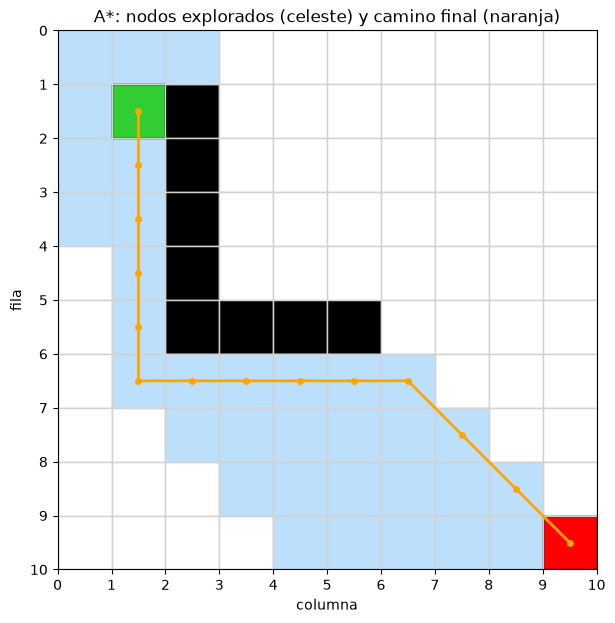

In [7]:
def mostrar_metricas(nombre, resultado):
    print(f"--- {nombre} ---")
    print(f"Costo total del camino : {resultado['costo']}")
    print(f"Cantidad de movimientos: {resultado['movimientos']}")
    print(f"Nodos explorados       : {resultado['nodos_explorados']}")
    print(f"Celdas del camino      : {resultado['celdas_camino']}")
    print(f"Tiempo de ejecucion    : {resultado['tiempo'] * 1000:.4f} ms")
    print("Camino:", " -> ".join(str(c) for c in resultado["camino"]))


mostrar_metricas("A*", resultado_astar)

explorados_astar = [p["celda"] for p in explorador_astar.pasos]
graficar_espacio(espacio, camino=resultado_astar["camino"], explorados=explorados_astar,
                  titulo="A*: nodos explorados (celeste) y camino final (naranja)")

## Parte 7 — Dijkstra

Reutilizamos `Explorador` con `usar_heuristica=False`: `h(n) = 0` para toda celda, por lo que `f(n) = g(n)` y la busqueda pasa a expandir por costo acumulado puro (Dijkstra), sin ninguna orientacion hacia la meta. Se usa exactamente el mismo `Espacio` (misma cuadricula, inicio, meta, obstaculos y costos de movimiento).

--- Dijkstra ---
Costo total del camino : 142
Cantidad de movimientos: 13
Nodos explorados       : 92
Celdas del camino      : 14
Tiempo de ejecucion    : 4.3459 ms
Camino: (1, 1) -> (2, 1) -> (3, 1) -> (4, 1) -> (5, 1) -> (6, 1) -> (6, 2) -> (6, 3) -> (6, 4) -> (6, 5) -> (6, 6) -> (7, 7) -> (8, 8) -> (9, 9)


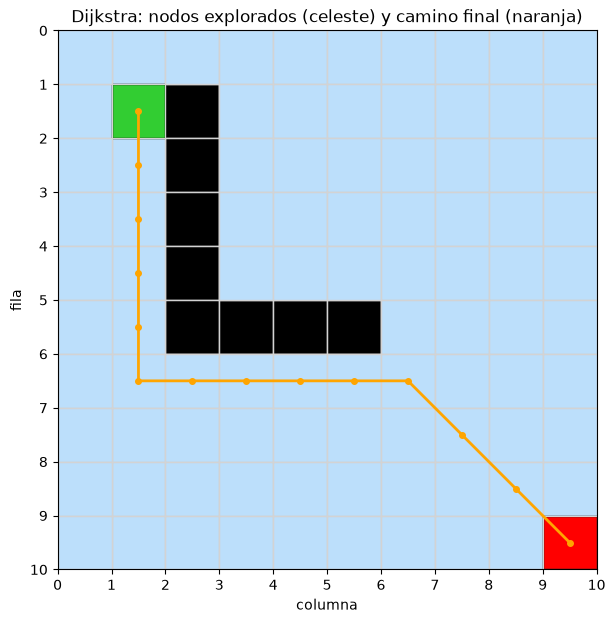

In [8]:
explorador_dijkstra = Explorador(espacio, usar_heuristica=False)
resultado_dijkstra = explorador_dijkstra.buscar()

mostrar_metricas("Dijkstra", resultado_dijkstra)

explorados_dijkstra = [p["celda"] for p in explorador_dijkstra.pasos]
graficar_espacio(espacio, camino=resultado_dijkstra["camino"], explorados=explorados_dijkstra,
                  titulo="Dijkstra: nodos explorados (celeste) y camino final (naranja)")

## Parte 8 — Comparacion y conclusiones

In [9]:
comparacion = pd.DataFrame({
    "Metrica": [
        "Costo total del camino",
        "Cantidad de movimientos",
        "Nodos explorados",
        "Celdas del camino",
        "Tiempo de ejecucion (ms)",
    ],
    "A*": [
        resultado_astar["costo"],
        resultado_astar["movimientos"],
        resultado_astar["nodos_explorados"],
        resultado_astar["celdas_camino"],
        round(resultado_astar["tiempo"] * 1000, 2),
    ],
    "Dijkstra": [
        resultado_dijkstra["costo"],
        resultado_dijkstra["movimientos"],
        resultado_dijkstra["nodos_explorados"],
        resultado_dijkstra["celdas_camino"],
        round(resultado_dijkstra["tiempo"] * 1000, 2),
    ],
})
comparacion

,Metrica,A*,Dijkstra
0,Costo total del camino,142.00,142.00
1,Cantidad de movimientos,13.00,13.00
2,Nodos explorados,35.00,92.00
3,Celdas del camino,14.00,14.00
4,Tiempo de ejecucion (ms),2.94,4.35


### Interpretacion de resultados

1. **¿Los dos algoritmos encontraron un camino con el mismo costo minimo?** Si: ambos devuelven el mismo *costo total del camino* en la tabla anterior. Es lo esperado porque ambos son algoritmos optimos para este tipo de grafo (pesos no negativos); A* con una heuristica admisible (la distancia octil nunca sobreestima el costo real) no sacrifica optimalidad, solo eficiencia.

2. **¿Encontraron necesariamente exactamente la misma secuencia de celdas?** No necesariamente: puede haber varios caminos distintos con igual costo total. En este escenario particular ambos coinciden, pero eso es una propiedad de esta cuadricula/obstaculos especifica, no una garantia general del algoritmo.

3. **¿Cual de los algoritmos exploro menos nodos?** A*. Al usar `h(n)` para priorizar los nodos que ademas de tener bajo `g(n)` estan orientados hacia la meta, A* descarta gran parte del espacio de busqueda que Dijkstra si expande en todas direcciones por igual.

4. **¿Que efecto produjo la funcion heuristica en A*?** Dirigio la expansion hacia la meta, reduciendo la cantidad de nodos explorados sin perder la garantia de optimalidad, porque la heuristica octil es admisible (nunca sobreestima el costo real restante).

5. **¿Que ocurre conceptualmente cuando se establece h(n)=0?** El algoritmo pierde toda informacion direccional; `f(n)` pasa a depender solo del costo acumulado `g(n)`, por lo que la seleccion de que nodo expandir se basa exclusivamente en "que tan barato fue llegar hasta ahi", no en "que tan cerca esta de la meta". Esto es exactamente la definicion de Dijkstra: A* con heuristica nula.

## Preguntas de analisis

**1. ¿Que representan g(n), h(n) y f(n) en A*?**
`g(n)` es el costo real acumulado desde el inicio hasta el nodo `n` (la suma de los costos de movimiento, 10 o 14, a lo largo del camino recorrido). `h(n)` es una estimacion heuristica del costo restante desde `n` hasta la meta (aqui, la distancia octil). `f(n) = g(n) + h(n)` es el costo total estimado de la mejor solucion que pasa por `n`, y es el valor que se usa para decidir que nodo de OPEN expandir a continuacion.

**2. ¿Por que para esta tarea no se utiliza directamente la distancia Manhattan empleada en el ejemplo 5x5 desarrollado en clase?**
La distancia Manhattan (`|dx| + |dy|`) asume que solo se puede mover en horizontal/vertical. Con movimientos diagonales disponibles, Manhattan sobreestima el costo real de moverse en diagonal (dos pasos rectos de costo 10 cada uno suman 20, cuando un solo paso diagonal cuesta 14), dejando de ser admisible y pudiendo hacer que A* devuelva un camino suboptimo.

**3. Explique con sus propias palabras como la heuristica utilizada considera los movimientos diagonales.**
La distancia octil calcula cuantos pasos diagonales (`min(dx, dy)`) alcanzan para acercarse simultaneamente en fila y columna, y el resto de la distancia (`max(dx, dy) - min(dx, dy)`) lo cubre con pasos rectos. Multiplicando cada tipo de paso por su costo real (14 y 10) se obtiene una estimacion que nunca sobreestima el costo verdadero, manteniendo la heuristica admisible.

**4. ¿Por que se asigno costo 10 al movimiento horizontal/vertical y 14 al diagonal?**
Porque geometricamente la diagonal de una celda cuadrada de lado 1 mide √2 ≈ 1.414, frente a 1 del lado recto. Para trabajar con enteros y evitar decimales, se escala todo por 10: 1x10=10 y √2x10≈14.14≈14, conservando la proporcion real entre ambos tipos de movimiento.

**5. ¿Como identifica el programa que una celda corresponde a un obstaculo y que ocurre cuando intenta generarla como sucesor?**
`Espacio.obstaculos` es un `set` de celdas prohibidas; `Espacio.es_obstaculo(celda)` (y por extension `es_transitable`) consulta ese conjunto. En `Explorador._movimiento_valido`, si el vecino calculado no es transitable (esta fuera de limites o es un obstaculo) la funcion devuelve `None` y esa celda directamente no se agrega a la lista de sucesores: nunca llega a formar parte de OPEN ni del camino final.

**6. ¿En que situacion debe actualizarse el valor de g(n) y, consecuentemente, f(n) de un nodo que ya habia sido descubierto?**
Cuando se genera un sucesor hacia una celda que ya fue descubierta anteriormente (esta en `mejor_g`) pero el nuevo camino hacia ella tiene un costo acumulado menor que el que ya se tenia registrado (`hijo.g < mejor_g[celda]`). En ese caso se reemplaza el `g` guardado, se recalcula `f = g + h` y el nuevo nodo (con su nuevo padre) se agrega a OPEN.

**7. ¿Que diferencia existe entre un nodo perteneciente a CLOSED y una celda definida como obstaculo?**
Un obstaculo es un estado *prohibido* del espacio de busqueda: nunca puede ser parte de OPEN ni del camino, sin importar el algoritmo. Un nodo en CLOSED es una celda *transitable* que ya fue seleccionada y expandida; una vez cerrado no se vuelve a considerar en esta implementacion, pero conceptualmente sigue siendo una celda valida del espacio, solo que ya procesada.

**8. ¿Que diferencias observo entre A* y Dijkstra en la cantidad de nodos explorados?**
Dijkstra exploro considerablemente mas nodos que A* (ver tabla comparativa de la Parte 8). Al no tener heuristica, Dijkstra expande "en circulos" por costo acumulado sin preferir ninguna direccion, mientras que A* prioriza los nodos que ademas estan cerca de la meta, evitando expandir gran parte del espacio que se aleja del objetivo.

**9. ¿Que funcion cumple la heuristica para reducir el espacio de busqueda?**
La heuristica introduce informacion sobre "hacia donde" conviene expandir, permitiendo que A* posponga nodos que, aunque baratos de alcanzar, estan lejos de la meta. Esto concentra la exploracion en la region del espacio de estados que realmente puede formar parte de un camino optimo, en vez de expandir uniformemente en todas direcciones como hace Dijkstra.

## Conclusion

Ambos algoritmos garantizan encontrar el camino de costo minimo en esta cuadricula, porque A* usa una heuristica admisible (la distancia octil nunca sobreestima el costo real de moverse con pasos rectos de costo 10 y diagonales de costo 14). La diferencia no esta en la calidad de la solucion sino en la eficiencia de la busqueda: A* aprovecha la posicion de la meta para descartar rapidamente regiones del espacio que no aportan al camino optimo, mientras que Dijkstra, al carecer de esa informacion (h(n)=0), expande el espacio de forma uniforme segun el costo acumulado. El manejo de obstaculos (incluida la restriccion de no cortar esquinas bloqueadas en diagonal) y la actualizacion de g(n) cuando se descubre un camino mas barato hacia un nodo ya visitado fueron los dos puntos donde mas cuidado hubo que tener para que la implementacion fuera correcta y optima.